In [1]:
import torch
import pandas as pd
from torch_geometric.data import Data
from pathlib import Path
import os
os.chdir(Path().cwd().parent)
from modelling import get_dataframes
from modelling.metrics.metricstracker import MetricsTracker
import datetime
from graph_modelling.utils.load_data import load_train_val_data, load_test_data


Running __init__.py for data pipeline...
Modelling package initialized

/opt/rocm/lib/libamd_smi.so: cannot open shared object file: No such file or directory
Unable to find amdsmi library try installing amd-smi-lib from your package manager


2025-03-17 23:05:31.089989: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-03-17 23:05:31.090067: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-03-17 23:05:31.090100: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-03-17 23:05:31.098340: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-03-17 23:05:32.018312: W tensorflow/compiler/

In [2]:
HABROK = bool(0)                  # set to True if using HABROK; it will print
                                  # all stdout to a .txt file to log progress
BASE_DIR = Path.cwd()
MODEL_PATH = BASE_DIR / "results" / "models"
DATA_DIR = BASE_DIR / "data" / "data_combined"
ALL_DIR = DATA_DIR / "all"

print("BASE_DIR: ", BASE_DIR)
print("MODEL_PATH: ", MODEL_PATH)

torch.manual_seed(34)             # set seed for reproducibility

N_HOURS_U = 72                    # number of hours to use for input
N_HOURS_Y = 24                    # number of hours to predict
N_HOURS_STEP = 24                 # "sampling rate" in hours of the data; e.g. 24 
                                  # means sample an I/O-pair every 24 hours
                                  # the contaminants and meteorological vars
CONTAMINANTS = ['NO2', 'O3'] # 'PM10', 'PM25']

BASE_DIR:  /home/nick/bachelor-project/forecasting_smog_DL_GNN
MODEL_PATH:  /home/nick/bachelor-project/forecasting_smog_DL_GNN/results/models


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)
current_time = datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

tracker = MetricsTracker(
    experiment_name='GNN',
    log_dir=BASE_DIR / "src" / 'results' / 'energy_logs',
    track_energy=True,
    track_tensorboard=True,
    track_memory=True,
    verbose=True,
)

cuda
[2025-03-17 23:05:32,509] [zeus.device.gpu.nvidia](nvidia.py:47) pynvml is available and initialized.
[2025-03-17 23:05:32,522] [zeus.device.cpu.rapl](rapl.py:137) RAPL is not supported on this CPU.
[2025-03-17 23:05:32,523] [zeus.monitor.energy](energy.py:209) Monitoring GPU indices [0].
[2025-03-17 23:05:32,524] [zeus.monitor.energy](energy.py:210) Monitoring CPU indices []
[2025-03-17 23:05:32,524] [zeus.monitor.energy](energy.py:219) Writing measurement logs to /home/nick/bachelor-project/forecasting_smog_DL_GNN/src/results/energy_logs/GNN_20250317_230532/energy_20250317_230532.csv.


In [4]:
import torch
import sys


cities = ["amsterdam", "rotterdam", "utrecht"]

# Load training data
train_features, train_labels = load_train_val_data(cities, is_train=True, ALL_DIR=ALL_DIR)

# Load validation data
val_features, val_labels = load_train_val_data(cities, is_train=False, ALL_DIR=ALL_DIR)


Node feature shape (train): torch.Size([3, 8])
Node label shape (train): torch.Size([3, 2])
Node feature shape (val): torch.Size([3, 8])
Node label shape (val): torch.Size([3, 2])


In [5]:

edges = [
    (0, 1), (1, 0),  # edge between city0 and city1 (bidirectional)
    (0, 2), (2, 0),  # edge between city0 and city2 (bidirectional)
    (1, 2), (2, 1)   # edge between city1 and city2 (bidirectional)
]

# Convert the edges into an edge_index tensor in PyG format
edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

print("Edge index:\n", edge_index)



Edge index:
 tensor([[0, 1, 0, 2, 1, 2],
        [1, 0, 2, 0, 2, 1]])


In [6]:
from torch_geometric.loader import DataLoader

train_data = Data(x=train_features, edge_index=edge_index, y=train_labels)
val_data = Data(x=val_features, edge_index=edge_index, y=val_labels)

In [7]:
from graph_modelling.models.basicgnn import BasicGNN
model = BasicGNN(input_dim=train_features.shape[1], output_dim=train_labels.shape[1])
model.to(device)


BasicGNN(
  (conv1): GCNConv(8, 16)
  (conv2): GCNConv(16, 2)
)

In [8]:
from graph_modelling.utils.train_gnn import train_gnn, train_epoch
# Patch train_epoch dynamically to include tracking
import graph_modelling.utils.train_gnn  # Import the module itself
graph_modelling.utils.train_gnn.train_epoch = tracker.track_window("epoch")(
    graph_modelling.utils.train_gnn.train_epoch
)

# Now call train_gnn – it will use the patched train_epoch
train_gnn(model, train_data, val_data, epochs=50, device=device, lr=0.01, BASE_DIR=BASE_DIR)

[2025-03-17 23:05:33,864] [zeus.monitor.energy](energy.py:209) Monitoring GPU indices [0].
[2025-03-17 23:05:33,865] [zeus.monitor.energy](energy.py:210) Monitoring CPU indices []
[2025-03-17 23:05:33,866] [zeus.monitor.energy](energy.py:219) Writing measurement logs to /home/nick/bachelor-project/forecasting_smog_DL_GNN/src/results/energy_logs/GNN_20250317_230533/energy_20250317_230533.csv.
[2025-03-17 23:05:33,868] [zeus.utils.framework](framework.py:25) PyTorch with CUDA support is available.
Starting tracking for epoch

Epoch 0:
  Train Loss: 0.0602
  Val Loss: 0.0219
  Epoch Energy: 16.69J
  Epoch Time: 0.73s
Epoch 0, Train Loss: 0.06015165150165558, Val Loss: 0.02192503772675991
Starting tracking for epoch

Epoch 1:
  Train Loss: 0.0260
  Val Loss: 0.0053
  Epoch Energy: 2.19J
  Epoch Time: 0.00s
Epoch 1, Train Loss: 0.026026520878076553, Val Loss: 0.005253431387245655
Starting tracking for epoch

Epoch 2:
  Train Loss: 0.0064
  Val Loss: 0.0003
  Epoch Energy: 0.00J
  Epoch Time

/home/nick/bachelor-project/forecasting_smog_DL_GNN/.venv/lib/python3.10/site-packages/zeus/monitor/energy.py:403: UserWarning: The energy consumption of one or more GPUs was measured as zero. This means that the time duration of the measurement window was shorter than the GPU's energy counter update period. Consider turning on the `approx_instant_energy` option in `ZeusMonitor`, which approximates the energy consumption of a short time window as instant power draw x window duration.
  warnings.warn(


Starting tracking for epoch

Epoch 28:
  Train Loss: 0.0015
  Val Loss: 0.0011
  Epoch Energy: 0.86J
  Epoch Time: 0.00s
Epoch 28, Train Loss: 0.001537372823804617, Val Loss: 0.0011180988512933254
Starting tracking for epoch

Epoch 29:
  Train Loss: 0.0011
  Val Loss: 0.0007
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 29, Train Loss: 0.00106642278842628, Val Loss: 0.0006713713519275188
Starting tracking for epoch

Epoch 30:
  Train Loss: 0.0006
  Val Loss: 0.0004
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 30, Train Loss: 0.0005855366471223533, Val Loss: 0.00035037589259445667
Starting tracking for epoch

Epoch 31:
  Train Loss: 0.0002
  Val Loss: 0.0002
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 31, Train Loss: 0.0002484831493347883, Val Loss: 0.00022553501185029745
Starting tracking for epoch

Epoch 32:
  Train Loss: 0.0001
  Val Loss: 0.0003
  Epoch Energy: 0.00J
  Epoch Time: 0.01s
Epoch 32, Train Loss: 0.00013238098472356796, Val Loss: 0.0002855188795365393
Starting t

Plotting memory metrics



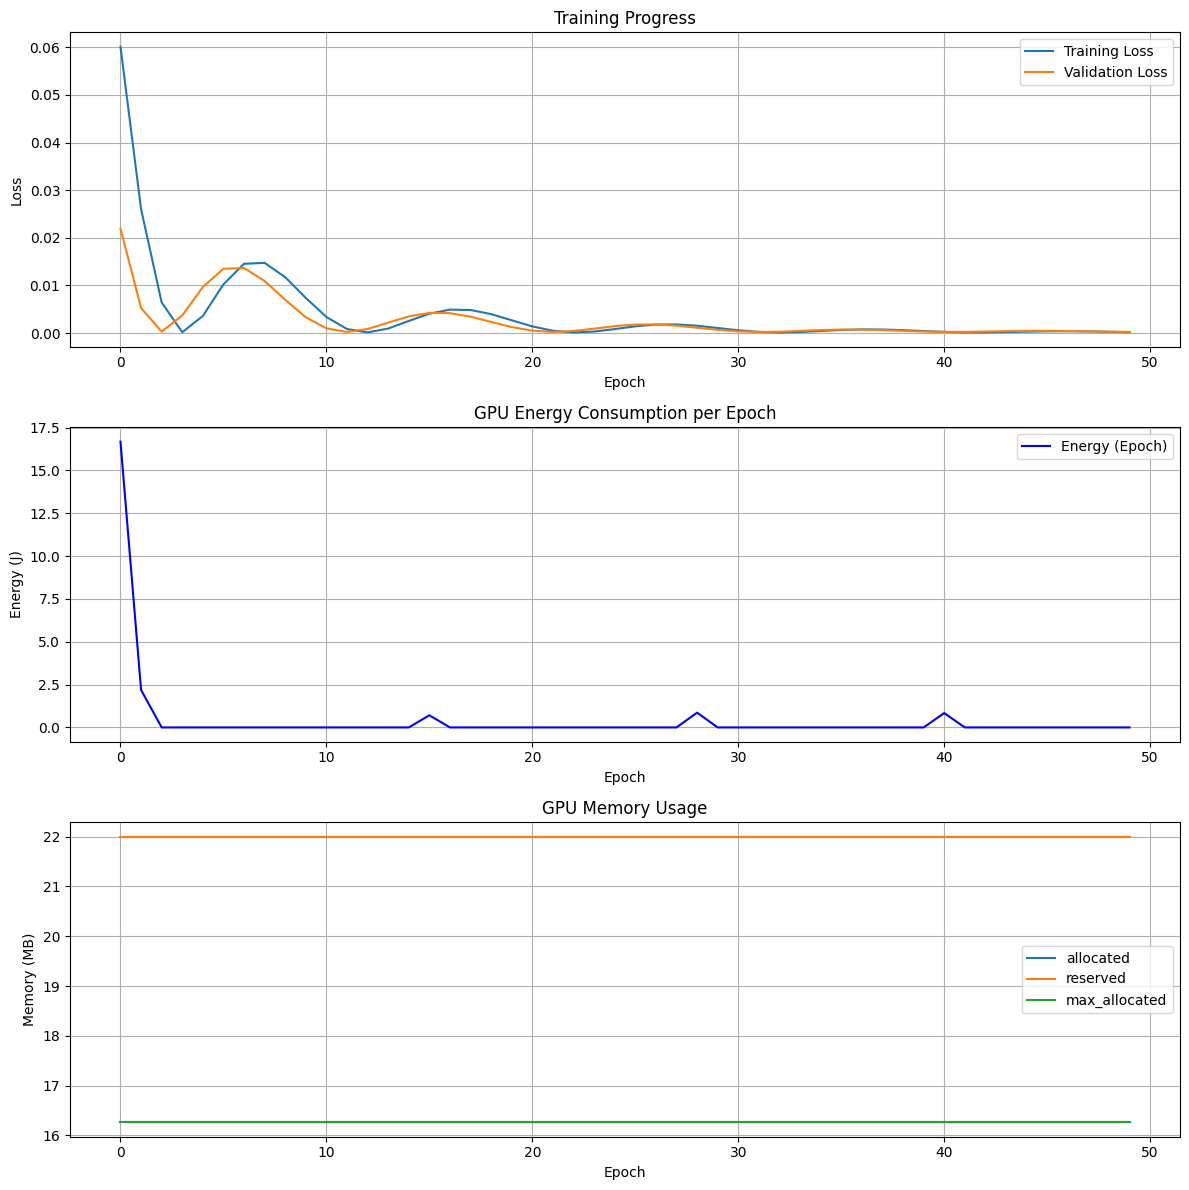

In [9]:
tracker.plot_metrics()

In [10]:
x_test, y_true = load_test_data(cities, ALL_DIR=ALL_DIR)
y_true.to(device)

tensor([[0.1873, 0.1696],
        [0.1878, 0.1411],
        [0.1464, 0.1528]], device='cuda:0')

In [11]:
test_data = Data(x=x_test, edge_index=edge_index)  # Use same edges
test_data.to(device)

model.eval()
with torch.no_grad():
    y_pred = model(test_data)
y_pred.to(device)

tensor([[0.1593, 0.2178],
        [0.1593, 0.2178],
        [0.1593, 0.2178]], device='cuda:0')

In [12]:
# rescale the predictions based on 'O3': {'min': -5.0, 'max': 205.0},
#  'NO2': {'min': -2.6, 'max': 177.6},

O3_min, O3_max = -5.0, 205.0
NO2_min, NO2_max = -2.6, 177.6

y_pred[:, 0] = y_pred[:, 0] * (O3_max - O3_min) + O3_min
y_pred[:, 1] = y_pred[:, 1] * (NO2_max - NO2_min) + NO2_min

y_true[:, 0] = y_true[:, 0] * (O3_max - O3_min) + O3_min
y_true[:, 1] = y_true[:, 1] * (NO2_max - NO2_min) + NO2_min

In [13]:
import torch.nn.functional as F

y_pred = y_pred.to(device)
y_true = y_true.to(device)

mse = F.mse_loss(y_pred, y_true)
rmse = torch.sqrt(mse)
print(f"Test RMSE: {rmse.item()}")


Test RMSE: 8.961610794067383


In [14]:
# MSE for NO2
mse_NO2 = F.mse_loss(y_pred[:, 1], y_true[:, 1])

# RMSE for NO2
rmse_NO2 = torch.sqrt(mse_NO2)

print(f"Test RMSE for NO2: {rmse_NO2.item()}")

# MSE for O3
mse_O3 = F.mse_loss(y_pred[:, 0], y_true[:, 0])

# RMSE for O3
rmse_O3 = torch.sqrt(mse_O3)

print(f"Test RMSE for O3: {rmse_O3.item()}")

Test RMSE for NO2: 11.609374046325684
Test RMSE for O3: 5.083638668060303
